### Marker gene identification for L2/3 excitatory cells

In [1]:
# From O'Toole and Keller 
# Gsta4, Timp2, Pea15a, Rfx3, Nov, Matn2, Cdh13, Adamts2, Cdh12, Nptx2, Rrad (corr Baz1a), Nptx2, Agmat

# From Jerry Chen
# Ngb, Fst, Rrad (corr Baz1a), Penk (corr Agmat), S100a6, Coch

# From zipursky 
# A) Cdh13 (corr Adamts2), B) Trpc6, and C) Chrm2 (corr Rorb)

In [2]:
## Imports + paths
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
from sklearn.mixture import GaussianMixture
import sys

DATA_DIR  = Path('/mnt/nasquatch/data/RNAseq/allenV1_SMART-seq')
CACHE_DIR = DATA_DIR / 'cache'
SRC_DIR   = Path('/mnt/nasquatch/data/analysis/josh/allen-scRNAseq-analysis/src')
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
sys.path.append('./src')

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 120

def read_parquet(path):
    import pyarrow.parquet as pq
    return pq.read_table(path).to_pandas()


In [3]:
## Load L2/3 IT excitatory cells (VISp clusters only)
# Use target_clusters to exclude the single ALM cell ('L2/3 IT ALM Sla')
# and filter directly in metadata — only the matching columns are read from the CSV.
import data_loader

VISP_L23_CLUSTERS = ['L2/3 IT VISp Agmat','L2/3 IT VISp Adamts2','L2/3 IT VISp Rrad'] # ,'L4 IT VISp Rspo1']


adata_l23_exc = data_loader.load_allen_filtered(
    metadata_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_samples-columns.csv'),
    expression_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_exon-matrix.csv'),
    target_class='Glutamatergic',
    target_layers=None,
    target_clusters=VISP_L23_CLUSTERS,
    genes_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_genes-rows.csv'),
    layer_name='counts',
    obsm_paths={'X_umap': f'{DATA_DIR}/cache/umap_exc.csv'},
)

if 'X_umap' not in adata_l23_exc.obsm:
    sc.pp.normalize_total(adata_l23_exc)
    sc.pp.log1p(adata_l23_exc)
    sc.pp.pca(adata_l23_exc)
    sc.pp.neighbors(adata_l23_exc)
    sc.tl.umap(adata_l23_exc)

    pd.DataFrame(
        adata_l23_exc.obsm['X_umap'],
        index=adata_l23_exc.obs_names,
        columns=['umap_1', 'umap_2'],
    ).to_csv(f'{DATA_DIR}/cache/umap_exc.csv') 

print(f'adata_l23_exc: {adata_l23_exc.n_obs} cells x {adata_l23_exc.n_vars} genes')
print()
print('Cluster breakdown:')
print(adata_l23_exc.obs['cluster'].value_counts().to_string()) 



Loading metadata from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_samples-columns.csv...
Loaded metadata: 15413 cells × 49 columns
Key columns: ['class', 'subclass', 'cluster']
Metadata filter: 627 of 15413 cells selected (class='Glutamatergic', layers=['L2/3'], clusters=['L2/3 IT VISp Agmat', 'L2/3 IT VISp Adamts2', 'L2/3 IT VISp Rrad'])
Loading expression matrix from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_exon-matrix.csv...
  Reading 627 of 15413 cell columns...
Loaded expression: 627 cells × 45768 genes
Creating AnnData with 627 cells

Cell classes: 1
class
Glutamatergic    627
Name: count, dtype: int64
Loading obsm embeddings...
  obsm['X_umap']: loaded shape (627, 2)
adata_l23_exc: 627 cells x 45768 genes

Cluster breakdown:
cluster
L2/3 IT VISp Agmat      430
L2/3 IT VISp Adamts2    127
L2/3 IT VISp Rrad        70


In [4]:
## Normalize, compute UMAP, and cache
UMAP_CACHE = CACHE_DIR / 'umap_glut_l23.csv'
N_HVG  = 2000
N_PCS  = 30
N_NEIGH = 20

# log1p(CPM) normalization in scanpy
sc.pp.normalize_total(adata_l23_exc, target_sum=1e6)
sc.pp.log1p(adata_l23_exc)

# Highly variable genes, PCA, neighbors, UMAP
sc.pp.highly_variable_genes(adata_l23_exc, n_top_genes=N_HVG, flavor='seurat')
sc.pp.scale(adata_l23_exc, max_value=10)
sc.tl.pca(adata_l23_exc, n_comps=N_PCS, use_highly_variable=True)
sc.pp.neighbors(adata_l23_exc, n_neighbors=N_NEIGH, n_pcs=N_PCS)
sc.tl.umap(adata_l23_exc, min_dist=0.3, random_state=42)

# Cache UMAP coordinates
umap_df = pd.DataFrame(
    adata_l23_exc.obsm['X_umap'],
    index=adata_l23_exc.obs_names,
    columns=['UMAP_1', 'UMAP_2'],
)
umap_df.to_csv(UMAP_CACHE)
print(f'UMAP cached to {UMAP_CACHE}')
print(f'UMAP shape: {adata_l23_exc.obsm["X_umap"].shape}')


/mnt/colab/colab_shared/anaconda3/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
2026-05-05 15:34:18.696801: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 15:34:20.807550: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2026-05-05 15:34:20.807731: W tensorflow/compiler/xla/stream_exe

UMAP cached to /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/cache/umap_glut_l23.csv
UMAP shape: (627, 2)


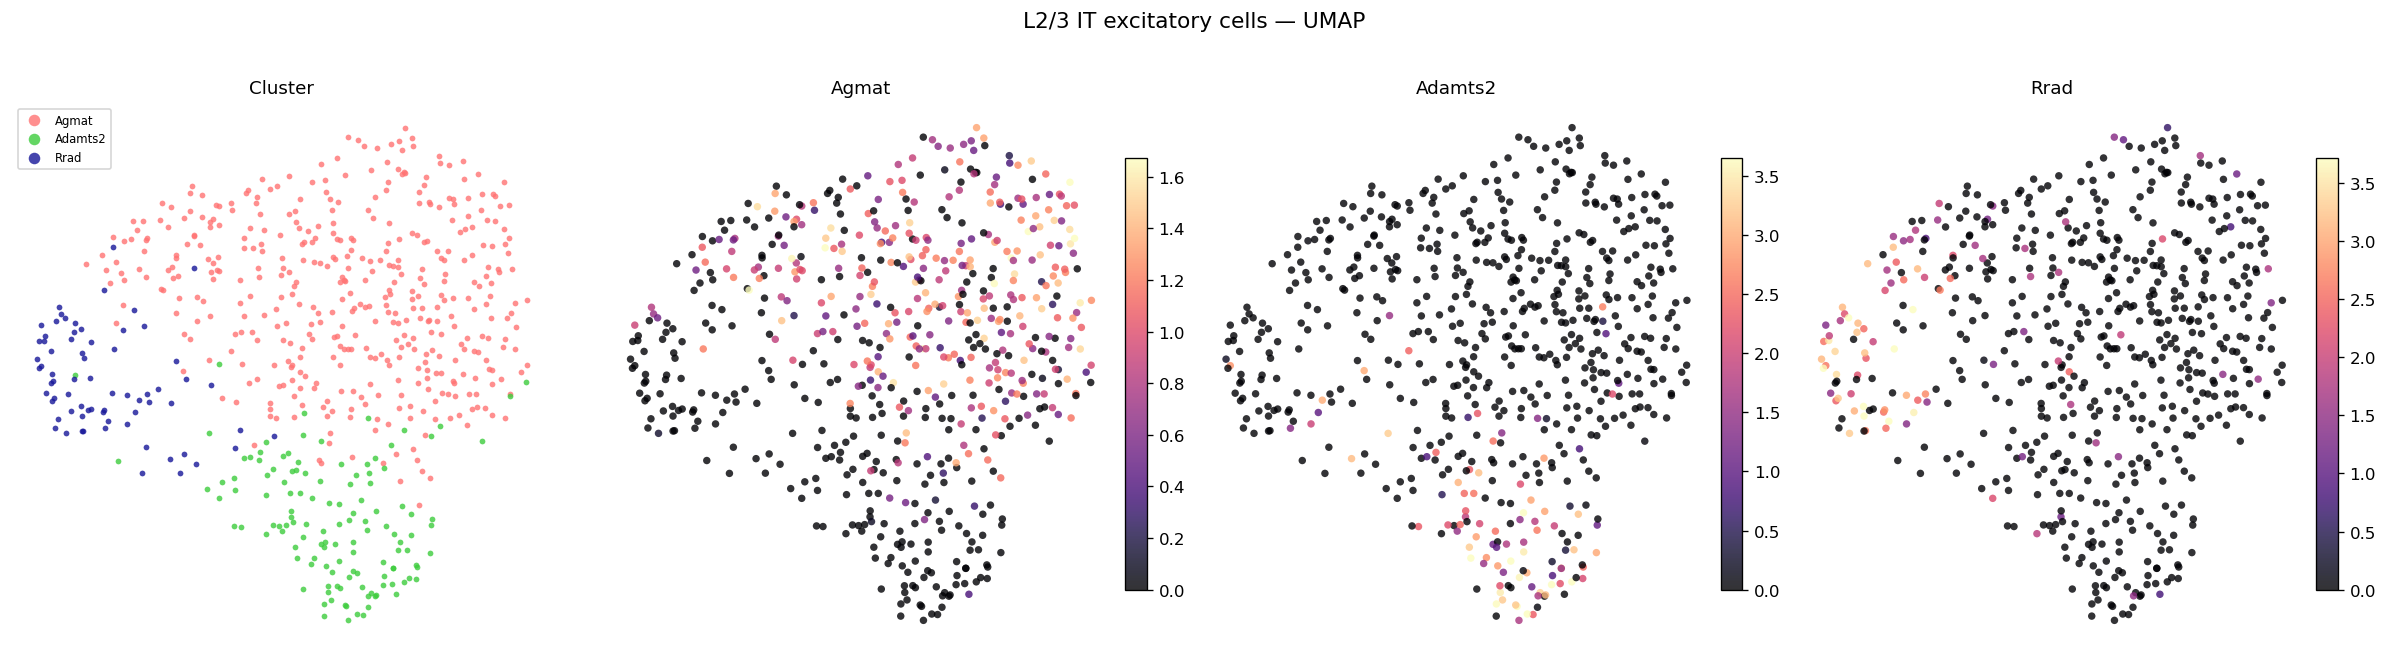

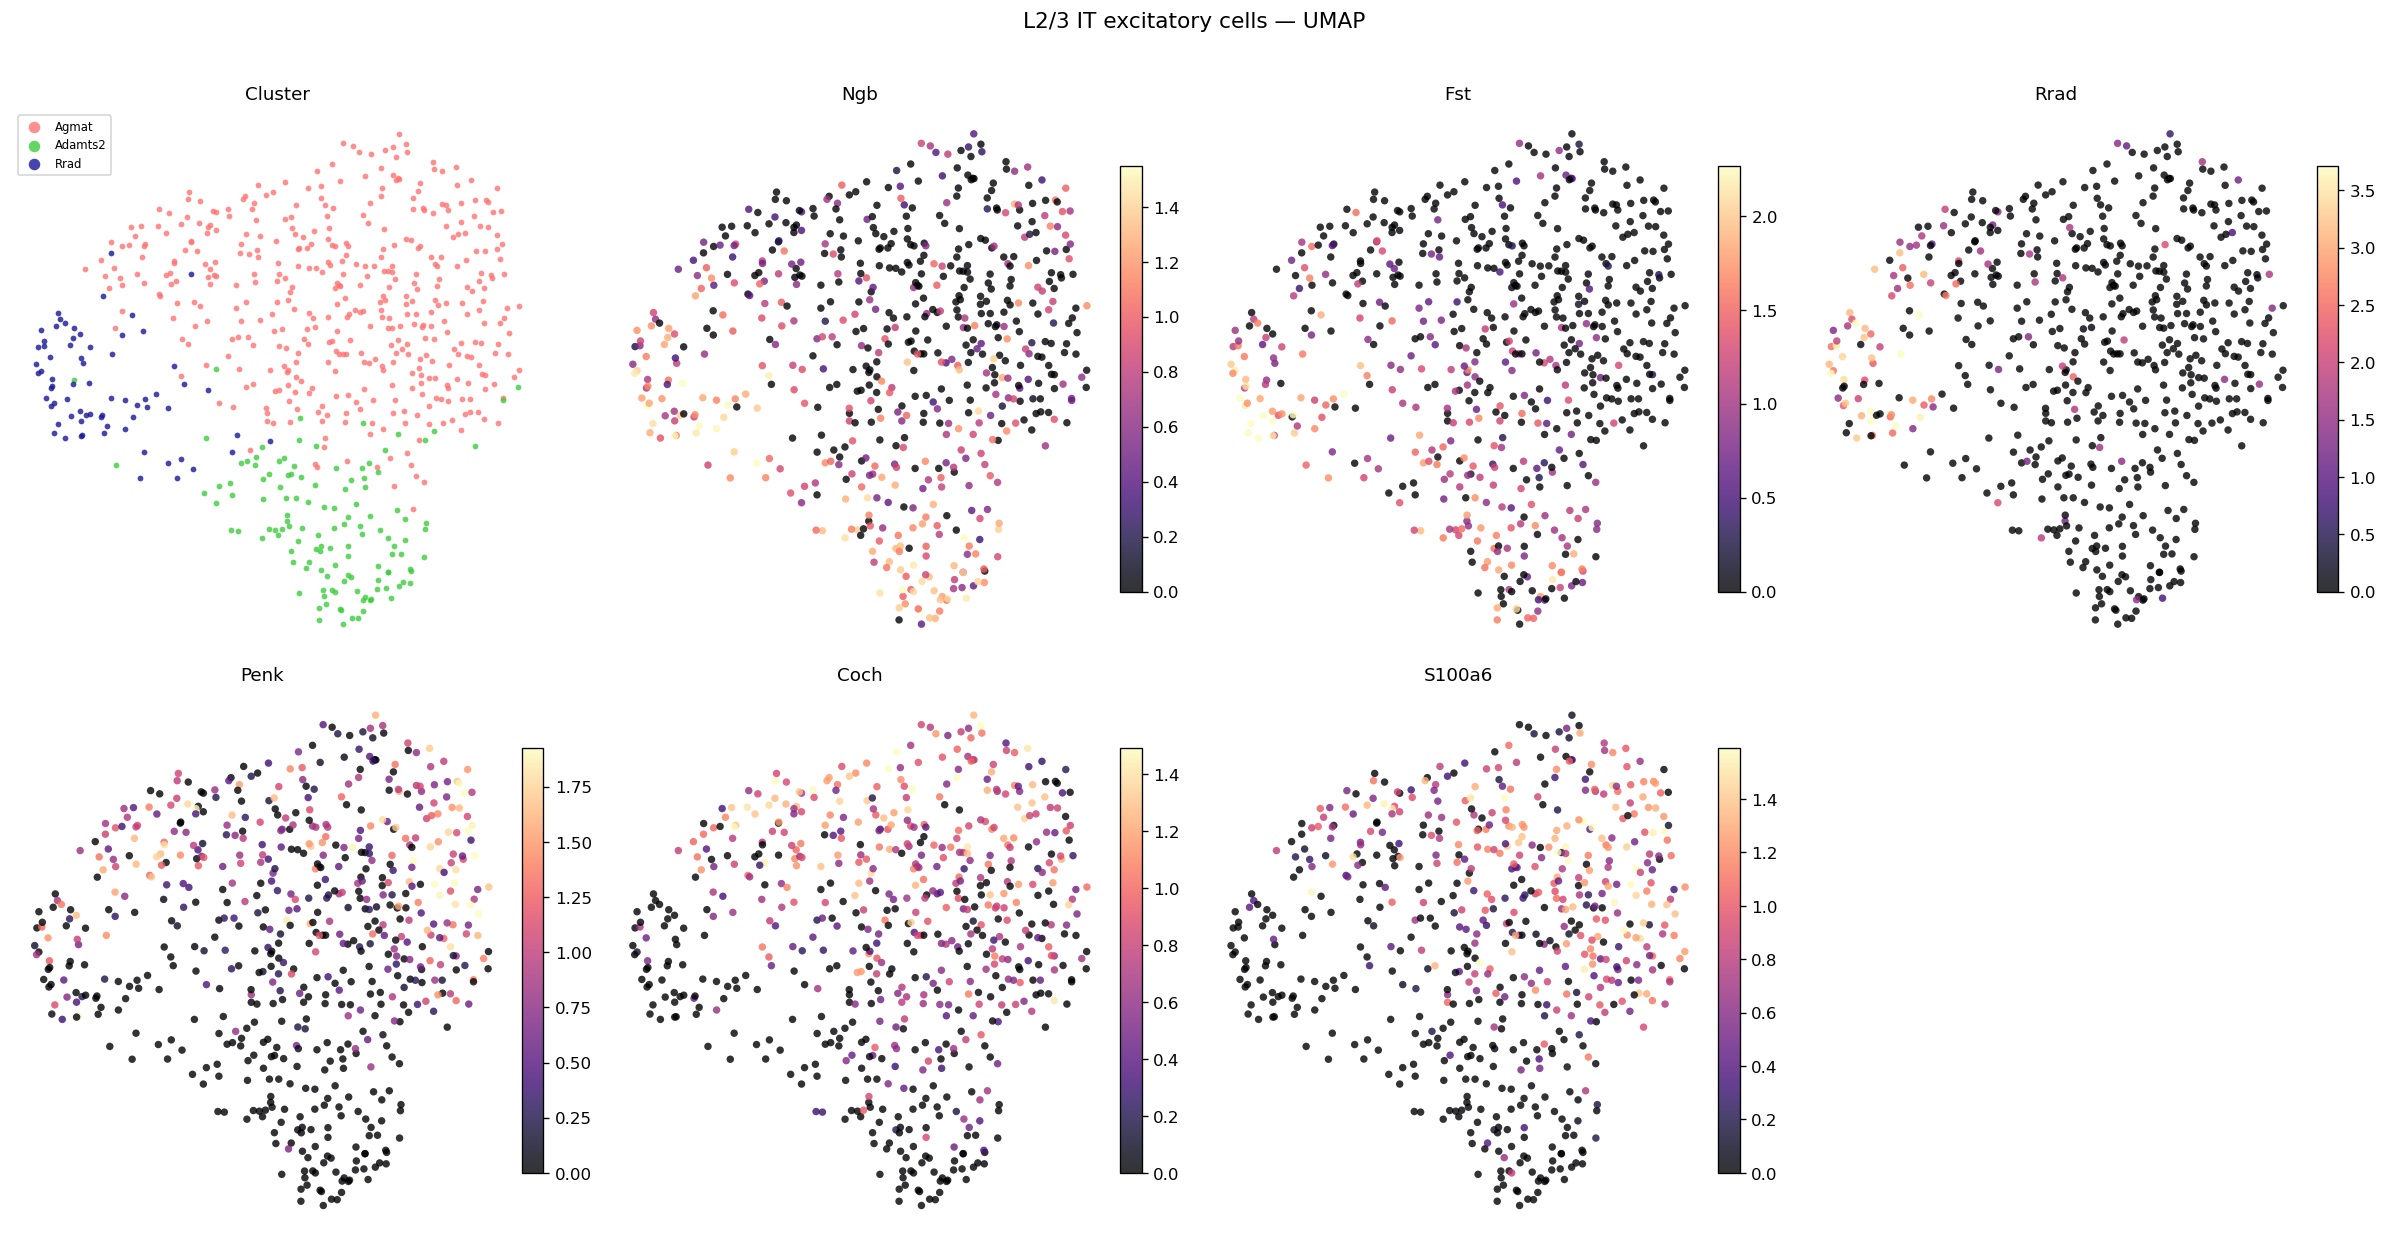

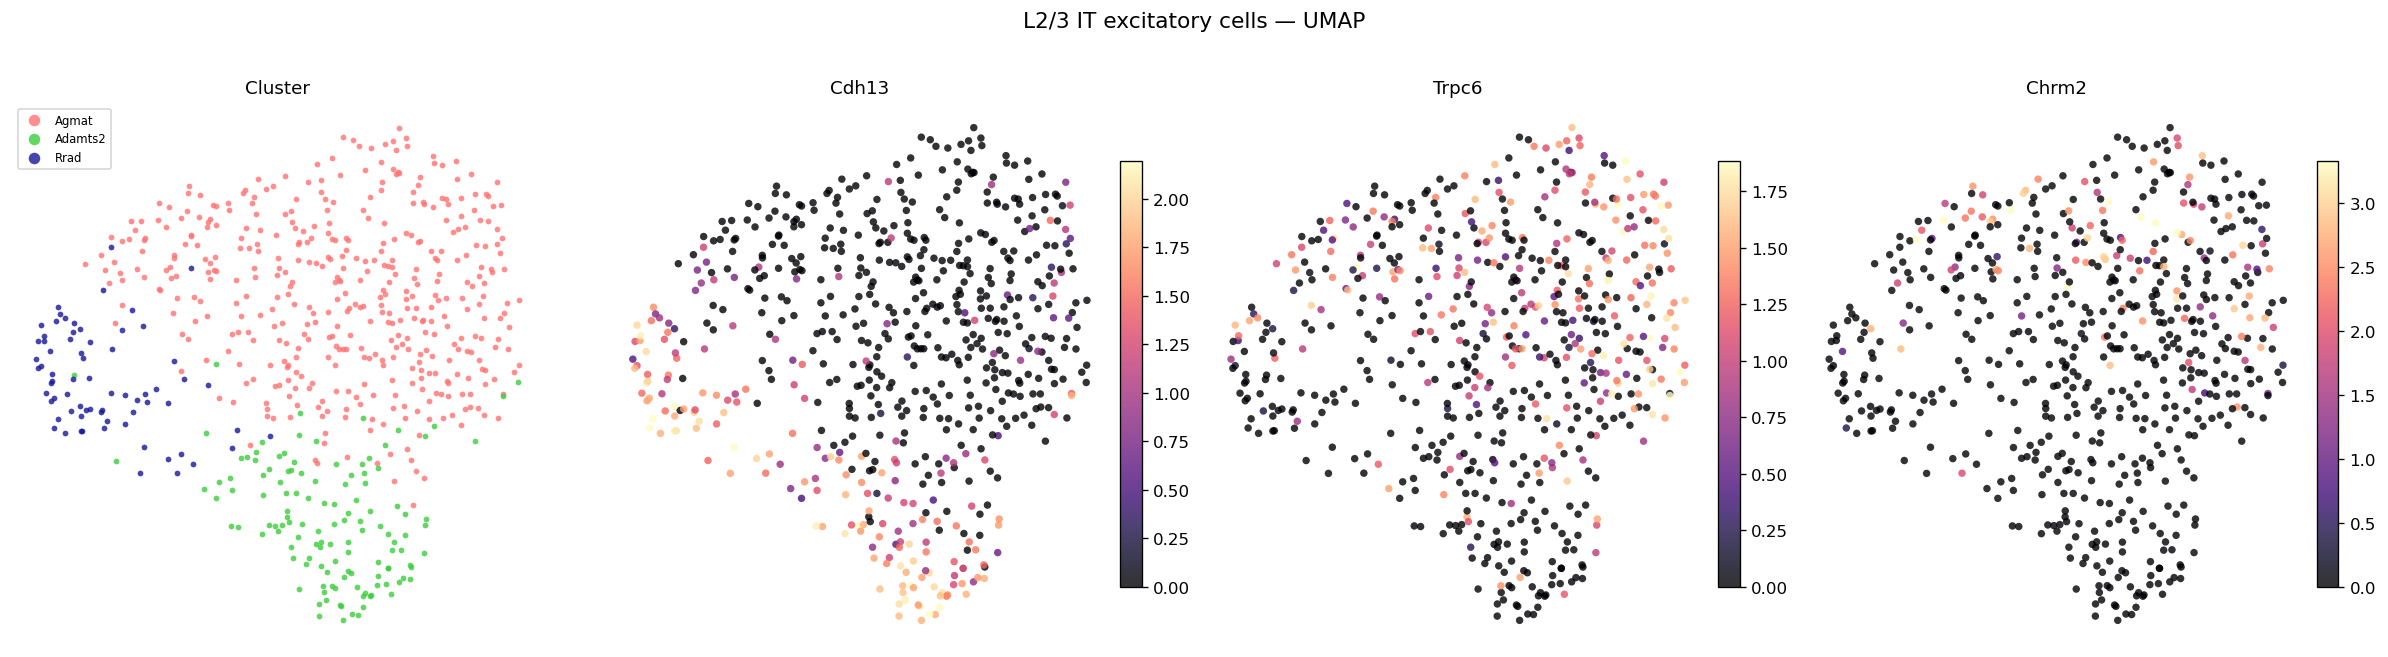

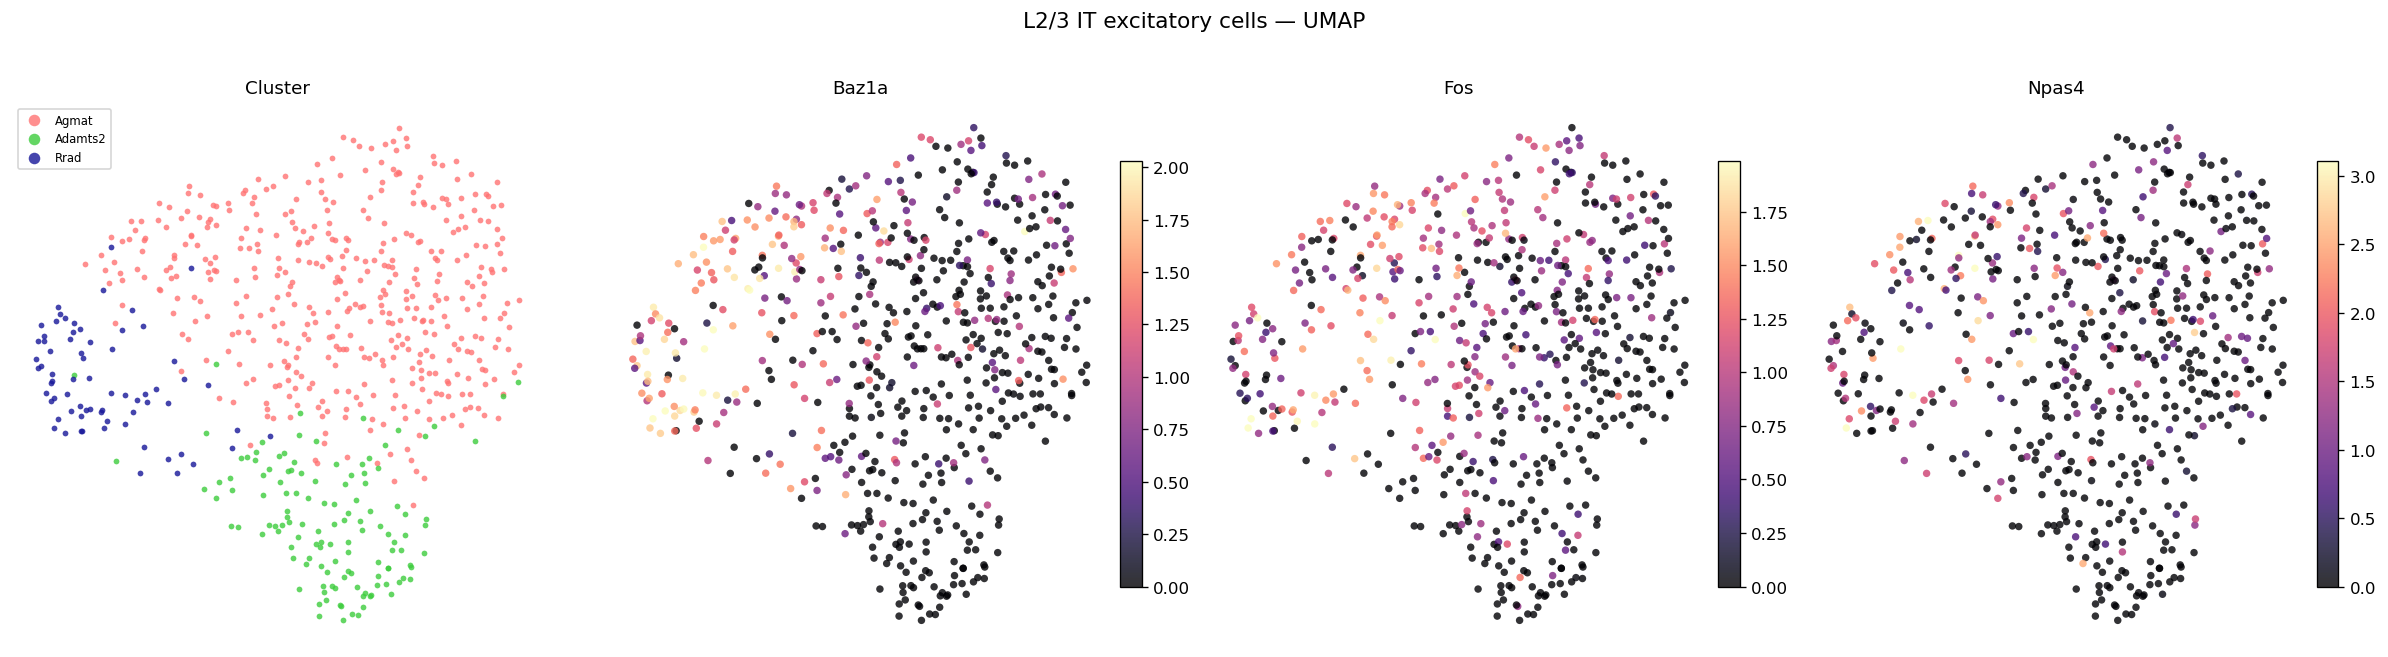

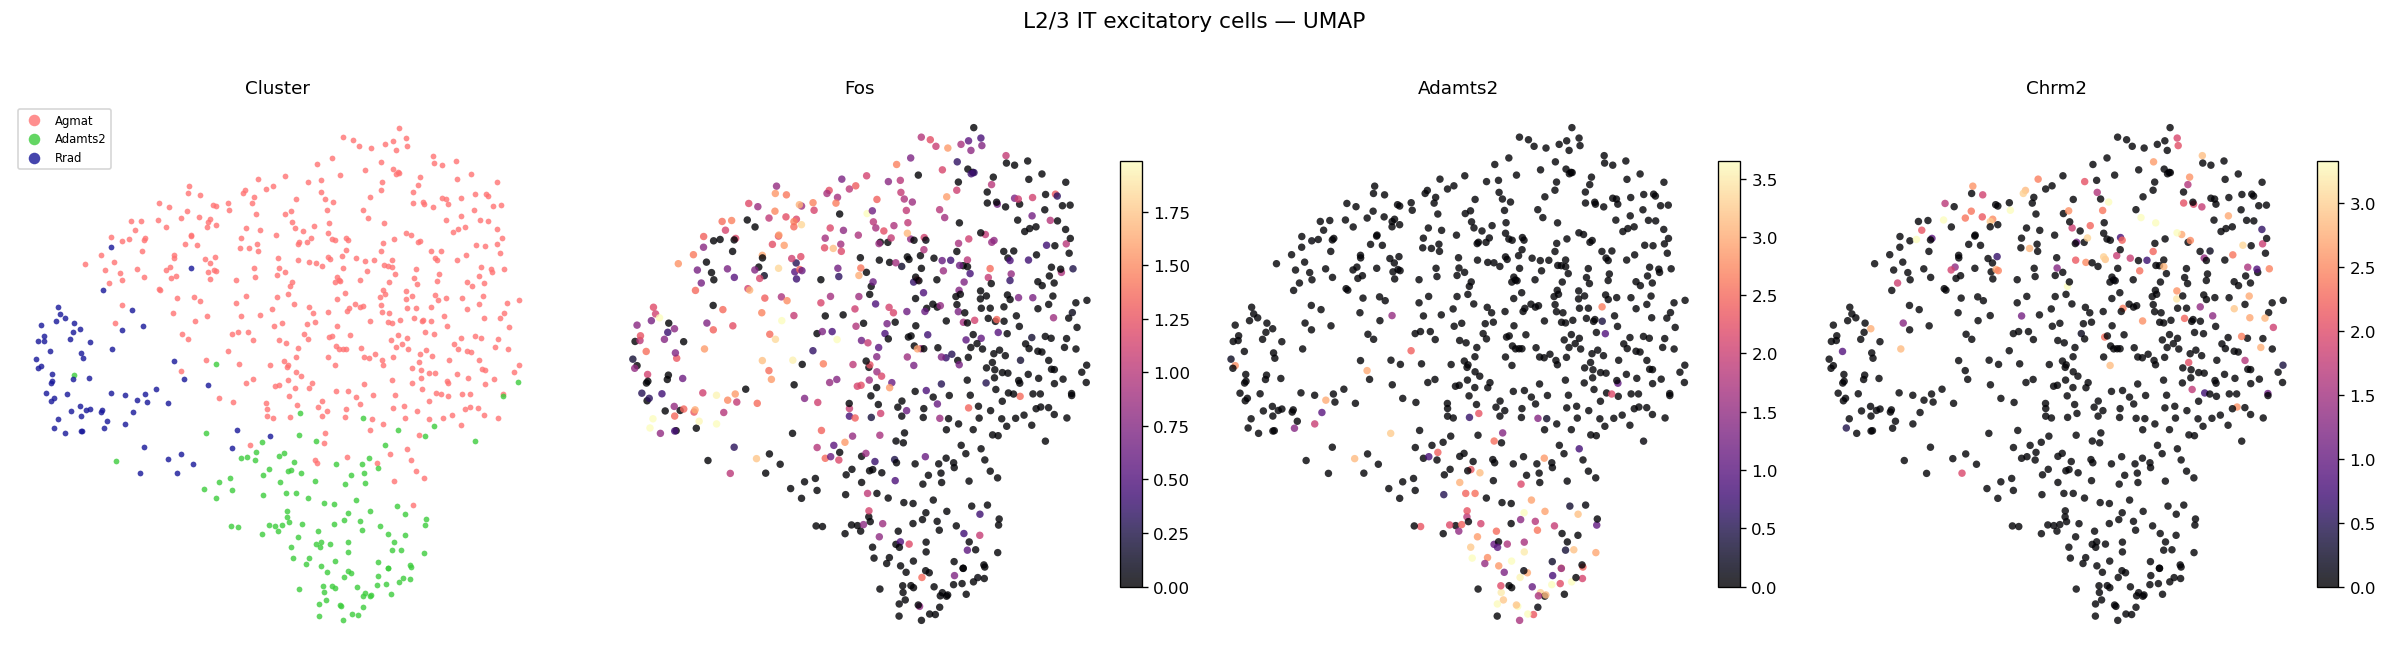

In [5]:
## Visualize UMAP: cluster identity + candidate marker genes
from matplotlib.colors import ListedColormap
import sys
sys.path.append('../src')
from visualization import varibow

umap_xy = adata_l23_exc.obsm['X_umap']

# Cluster color palette
clusters = adata_l23_exc.obs['cluster'].values.astype(str)
cluster_order = sorted(set(clusters), key=lambda c: -np.sum(clusters == c))  # descending by size
palette = varibow(len(cluster_order))
cluster_color = {c: palette[i] for i, c in enumerate(cluster_order)}

# Candidate marker genes (from literature)
allen_markers = ['Agmat', 'Adamts2', 'Rrad'] 
chen_markers = ['Ngb', 'Fst', 'Rrad','Penk','Coch','S100a6']
zipursky_markers = ['Cdh13', 'Trpc6', 'Chrm2']
ieg_markers = ['Baz1a', 'Fos', 'Npas4']
in_house_markers = ['Fos', 'Adamts2','Chrm2']

for MARKERS in [allen_markers , chen_markers,zipursky_markers,ieg_markers,in_house_markers]:

    # Filter to genes present in adata
    gene_sym = adata_l23_exc.var['gene_symbol'].values if 'gene_symbol' in adata_l23_exc.var.columns else adata_l23_exc.var_names
    sym_to_col = {s: i for i, s in enumerate(gene_sym)}
    present_markers = [g for g in MARKERS if g in sym_to_col]
    missing = [g for g in MARKERS if g not in sym_to_col]
    if missing:
        print(f'Markers not found in dataset: {missing}')

    n_marker_panels = len(present_markers)
    n_cols = 4
    n_rows = 1 + (n_marker_panels + n_cols - 1) // n_cols  # cluster row + marker rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    # Panel 0: cluster identity
    ax = axes[0]
    for cl in cluster_order:
        idx = np.where(clusters == cl)[0]
        ax.scatter(umap_xy[idx, 0], umap_xy[idx, 1],
                c=[cluster_color[cl]], s=12, alpha=0.8, linewidths=0,
                label=cl.replace('L2/3 IT VISp ', '').replace('L2/3 IT ALM ', 'ALM '),
                rasterized=True)
    ax.set_title('Cluster', fontsize=11)
    ax.axis('off')
    ax.legend(fontsize=7, markerscale=2, loc='best', framealpha=0.8)

    # Panels 1+: marker gene expression
    for j, gene in enumerate(present_markers):
        ax = axes[j + 1]
        col_idx = sym_to_col[gene]
        expr = adata_l23_exc.X[:, col_idx]
        if hasattr(expr, 'toarray'):
            expr = expr.toarray().ravel()
        vmax = float(np.percentile(expr, 99)) or 1.0
        sc_plot = ax.scatter(umap_xy[:, 0], umap_xy[:, 1],
                            c=expr, cmap='magma', s=20, alpha=0.8, linewidths=0,
                            vmin=0, vmax=vmax, rasterized=True)
        ax.set_title(gene, fontsize=11)
        ax.axis('off')
        plt.colorbar(sc_plot, ax=ax, fraction=0.04, pad=0.02)

    # Hide unused axes
    for ax in axes[n_marker_panels + 1:]:
        ax.set_visible(False)

    fig.suptitle('L2/3 IT excitatory cells — UMAP', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


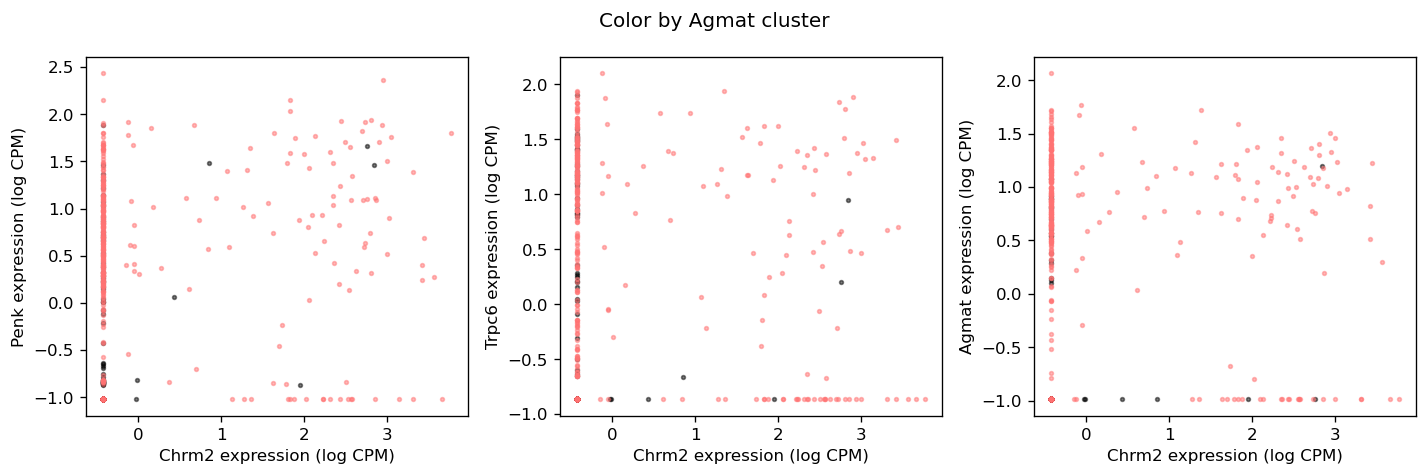

In [13]:
gene1 = 'Penk'
gene2 = 'Chrm2'
gene3 = 'Trpc6'
gene4 = 'Agmat'
col_idx1 = sym_to_col[gene1]
expr1 = adata_l23_exc.X[:, col_idx1]
col_idx2 = sym_to_col[gene2]
expr2 = adata_l23_exc.X[:, col_idx2]
col_idx3 = sym_to_col[gene3]
expr3 = adata_l23_exc.X[:, col_idx3]

col_idx4 = sym_to_col[gene4]
expr4 = adata_l23_exc.X[:, col_idx4]

agmat_mask = clusters == 'L2/3 IT VISp Agmat'

fig,ax = plt.subplots(1,3,figsize = (12,4))
ax[0].scatter(expr2[~agmat_mask],expr1[~agmat_mask],s = 5,color = 'k',alpha= .5)
ax[0].scatter(expr2[agmat_mask],expr1[agmat_mask],s = 5,color = cluster_color['L2/3 IT VISp Agmat'],alpha= .5)
ax[1].scatter(expr2[~agmat_mask],expr3[~agmat_mask],s = 5,color = 'k',alpha= .5)
ax[1].scatter(expr2[agmat_mask],expr3[agmat_mask],s = 5,color = cluster_color['L2/3 IT VISp Agmat'],alpha= .5)
ax[2].scatter(expr2[~agmat_mask],expr4[~agmat_mask],s = 5,color = 'k',alpha= .5)
ax[2].scatter(expr2[agmat_mask],expr4[agmat_mask],s = 5,color = cluster_color['L2/3 IT VISp Agmat'],alpha= .5)
[this_ax.set_xlabel('Chrm2 expression (log CPM)') for this_ax in ax.ravel()]
ax[0].set_ylabel('Penk expression (log CPM)')
ax[1].set_ylabel('Trpc6 expression (log CPM)')
ax[2].set_ylabel('Agmat expression (log CPM)')
fig.suptitle('Color by Agmat cluster') 
fig.tight_layout()

Text(0.5, 0.98, 'Color by Rrad cluster')

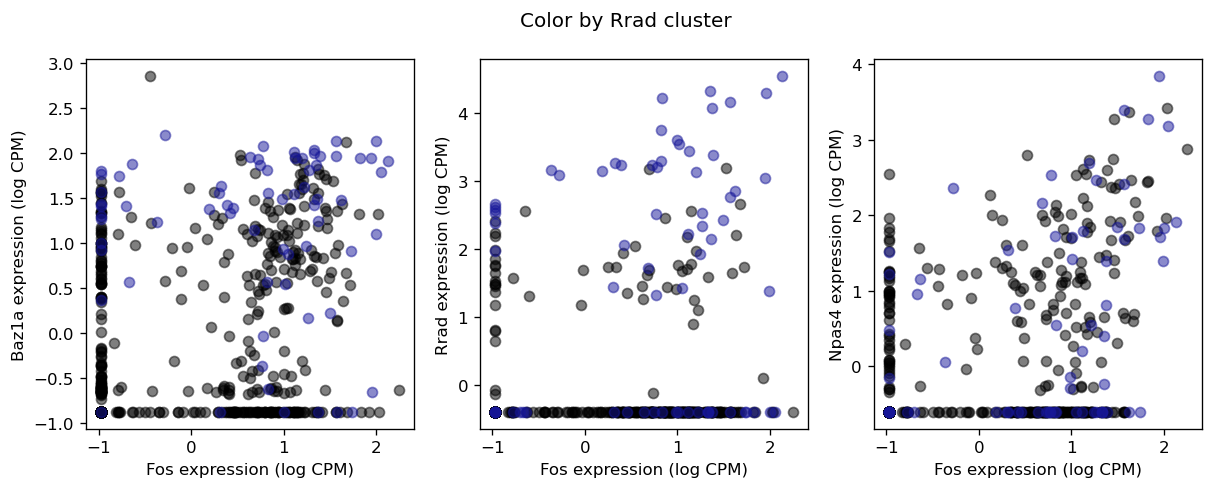

In [ ]:
gene1 = 'Baz1a' 
gene2 = 'Fos' 
gene3 = 'Rrad' 
gene4 = 'Npas4'
col_idx1 = sym_to_col[gene1]
expr1 = adata_l23_exc.X[:, col_idx1] 
col_idx2 = sym_to_col[gene2]
expr2 = adata_l23_exc.X[:, col_idx2]  
col_idx3 = sym_to_col[gene3]
expr3 = adata_l23_exc.X[:, col_idx3]  

col_idx4 = sym_to_col[gene4]
expr4 = adata_l23_exc.X[:, col_idx4] 

rrad_mask = clusters == 'L2/3 IT VISp Rrad'

fig,ax = plt.subplots(1,3,figsize = (12,4))  
ax[0].scatter(expr2[~rrad_mask],expr1[~rrad_mask],color = 'k',alpha= .5) 
ax[0].scatter(expr2[rrad_mask],expr1[rrad_mask],color = cluster_color['L2/3 IT VISp Rrad'],alpha= .5) 
ax[1].scatter(expr2[~rrad_mask],expr3[~rrad_mask],color = 'k',alpha= .5) 
ax[1].scatter(expr2[rrad_mask],expr3[rrad_mask],color = cluster_color['L2/3 IT VISp Rrad'],alpha= .5)  
ax[2].scatter(expr2[~rrad_mask],expr4[~rrad_mask],color = 'k',alpha= .5) 
ax[2].scatter(expr2[rrad_mask],expr4[rrad_mask],color = cluster_color['L2/3 IT VISp Rrad'],alpha= .5) 
[this_ax.set_xlabel('Fos expression (log CPM)') for this_ax in ax.ravel()]
ax[0].set_ylabel('Baz1a expression (log CPM)') 
ax[1].set_ylabel('Rrad expression (log CPM)') 
ax[2].set_ylabel('Npas4 expression (log CPM)') 
fig.suptitle('Color by Rrad cluster')

In [ ]:
# Logic from JChen: 
# Adamts2: (Fst or Ngb) and not (Penk or Rrad or S100a6 or Coch)
# Baz1a: (Penk or Rrad) and (Fst or Ngb or S100a6 or Coch) 
# Agmat: (S100a6 or Coch) and not(Penk or Rrad or Fst or Ngb)
